# Homework 7 Template

Rixin Li & G . Besla



In [ ]:
 # Make edits where instructed - look for "****", which indicates where you need to add code. 

In [16]:
# import necessary modules
# numpy provides powerful multi-dimensional arrays to hold and manipulate data
import numpy as np
# matplotlib provides powerful functions for plotting figures
import matplotlib.pyplot as plt
# astropy provides unit system and constants for astronomical calculations
import astropy.units as u
import astropy.constants as const
# import Latex module so we can display the results with symbols
from IPython.display import Latex
%matplotlib inline

# **** import CenterOfMass to determine the COM pos/vel of M33
from CenterOfMass2 import CenterOfMass

# **** import the GalaxyMass to determine the mass of M31 for each component
from GalaxyMass import ComponentMass

# M33AnalyticOrbit

In [23]:
class M33AnalyticOrbit:
    """ Calculate the analytical orbit of M33 around M31 """
    
    def __init__(self, filename): #add inputs
        """ This class will include a variety of functions that will determine
            the acceleration M33 feels from M31. It will integrate its current position 
            and velocity forwards in time
            
            Input: 
                filename: 'parameter' - output file that will store integrated orbit
                
        """

        #get the gravitational constant (the value is 4.498502151575286e-06)
        self.G = const.G.to(u.kpc**3/u.Msun/u.Gyr**2).value
        
        #store the output file name
        self.filename = filename
        
        ### get the current pos/vel of M33
        #creating an instance of the  CenterOfMass class for M33 
        M33_COM = CenterOfMass(filename='M33_000.txt', ptype=2)

        #Storing the position VECTOR of the M33 COM (.value to get rid of units)
        self.r_M33 = M33_COM.COM_P(0.1,2).value

        # **** store the velocity VECTOR of the M33 COM (.value to get rid of units)
        self.v_M33 = M33_COM.COM_V(self.r_M33[0]*u.kpc, self.r_M33[1]*u.kpc, self.r_M33[2]*u.kpc).value
        
        #get the current pos/vel of M31 
        #create an instance of the  CenterOfMass class for M31 
        M31_COM = CenterOfMass(filename='M31_000.txt', ptype=2)

        #store the position VECTOR of the M31 COM (.value to get rid of units)
        self.r_M31 = M31_COM.COM_P(0.1,4).value

        #store the velocity VECTOR of the M31 COM (.value to get rid of units)
        self.v_M31 = M31_COM.COM_V(self.r_M31[0]*u.kpc, self.r_M31[1]*u.kpc, self.r_M31[2]*u.kpc).value
        
        ### store the DIFFERENCE between the vectors posM33 - posM31
        #create two VECTORs self.r0 and self.v0 and have them be the
        # relative position and velocity VECTORS of M33
        self.r = self.r_M33 - self.r_M31
        self.v = self.v_M33 - self.v_M31
        
        ### get the mass of each component in M31 
        ### disk
        self.rdisk = 5

        #self.Mdisk set with ComponentMass function. Remember to *1e12 to get the right units. Use the right ptype
        self.Mdisk = ComponentMass(filename = "M31_000.txt", particle_type=2)*1e12
        
        ### bulge
        self.rbulge = 1

        #self.Mbulge  set with ComponentMass function. Remember to *1e12 to get the right units Use the right ptype
        self.Mbulge = ComponentMass(filename = "M31_000.txt", particle_type=3)*1e12
        
        # Halo
        # **** self.rhalo = set scale length from HW5 (no units)
        self.rhalo = 67

        #self.Mhalo set with ComponentMass function. Remember to *1e12 to get the right units. Use the right ptype
        self.Mhalo = ComponentMass(filename = "M31_000.txt", particle_type=1)*1e12
    
    
    def HernquistAccel(self, M, r_a, r): # it is easiest if you take as an input the position VECTOR 
        """ This function computes the gravitation acceleration in duced by a Hernquist profile
        
        Inputs:
            M: 'float' - total halo OR bulge mass
            r_a: 'float' - corresponding scale length
            r: 'vector' - relative position vector
        Outputs:
            Hern: 'vector' - acceleration vector from a Hernquist potential
        """
        
        #Store the magnitude of the position vector
        rmag = np.sqrt(r[0]**2 + r[1]**2 + r[2]**2)
        
        #Store the Acceleration
        Hern = -self.G*M/(rmag *(r_a + rmag)**2) * r #follow the formula in the HW instructions
        # NOTE: we want an acceleration VECTOR so you need to make sure that in the Hernquist equation you 
        # use  -G*M/(rmag *(ra + rmag)**2) * r --> where the last r is a VECTOR 
        
        return Hern
    
    
    
    def MiyamotoNagaiAccel(self, M, r_d, r):# it is easiest if you take as an input a position VECTOR  r 
        """ This function uses an approximation that mimics the exponential disk profile at 
               distances far from the disk, called a Miyamoto-Nagai 1975 profile.
               
               Inputs:
                   M: 'float' - total disk mass
                   r_d: 'float' - magnitude of the disk position
                   r: 'vector' - relative position vector
               Outputs:
                   MNAccel: 'vector' acceleration profile from the Miyamoto-Nagai profile
        """
        
        ### Acceleration **** follow the formula in the HW instructions
        # AGAIN note that we want a VECTOR to be returned  (see Hernquist instructions)
        # this can be tricky given that the z component is different than in the x or y directions. 
        # we can deal with this by multiplying the whole thing by an extra array that accounts for the 
        # differences in the z direction:
        #  multiply the whle thing by :   np.array([1,1,ZSTUFF]) 
        # where ZSTUFF are the terms associated with the z direction
        R = np.sqrt(r[0]**2 + r[1]**2)
        z_d = self.rdisk/5.0
        B = r_d + np.sqrt(r[2]**2 + z_d**2)
        MNAccel = (-self.G*M) / (R**2 + B**2)**1.5 *r 
        MNAccel = MNAccel* np.array([1, 1, B/np.sqrt(r[2]**2 + z_d**2)])
        
        return MNAccel
        # the np.array allows for a different value for the z component of the acceleration
     
    
    def M31Accel(self, r): # input should include the position vector, r
        """Sums all acceleration vectors from each galaxy component
            Inputs:
                r: '3D vector' - relative position vector
            Outputs:
                TotAccel: '3D vector' - total acceleration
        """

        ### Call the previous functions for the halo, bulge and disk
        #these functions will take as inputs variable we defined in the initialization of the class like 
        # self.rdisk etc. 
        a_halo = self.HernquistAccel(M=self.Mhalo, r_a=self.rhalo, r=r)
        a_bulge = self.HernquistAccel(M=self.Mbulge, r_a=self.rbulge, r=r)
        a_disk = self.MiyamotoNagaiAccel(M=self.Mdisk, r_d=self.rdisk, r=r)
        
        TotAccel = a_halo + a_bulge + a_disk
            
        # return the SUM of the output of the acceleration functions - this will return a VECTOR 
        return TotAccel
    
    
    
    def LeapFrog(self, dt, r, v): # take as input r and v, which are VECTORS. Assume it is ONE vector at a time
        """ This function solves the orbit of M33 by integrating the equation of motion 
            forwards in time
            Inputs:
                dt: 'float' - time interval for integration
                r: 'vector' - starting position vector for the M33 COM position relative to the M31
                v: 'vector'  starting velocity vector for the M33 relative to M31
            Outputs:
                rnew: 'vector' - position after a time step
                vnew: 'vector' - velocity after a time step
        """
        
        # predict the position at the next half timestep
        rhalf = r + v*(dt/2)
        
        # predict the final velocity at the next timestep using the acceleration field at the rhalf position 
        vnew = v + self.M31Accel(rhalf)*dt
        
        # predict the final position using the average of the current velocity and the final velocity
        # this accounts for the fact that we don't know how the speed changes from the current timestep to the 
        # next, so we approximate it using the average expected speed over the time interval dt. 
        rnew = r + 0.5*(v+vnew)*dt
        
        return rnew, vnew #returns the new position and velcoity vectors
    
    
    
    def OrbitIntegration(self, t0, dt, tmax):
        """ This function loops over the LeapFrog integrator to solve 
         the equations of motion and compute the future orbit of M33 for 10 Gyr into the future
             Inputs:
                 t0: 'float' - starting time
                 dt: 'float' - time interval
                 tmax: 'float' final time
             Outputs:
                orbit_traj: 'vector array' - stores entire trajectory of position and velocity vectors
        """

        # initialize the time to the input starting time
        t = t0
        
        # initialize an empty array of size :  rows int(tmax/dt)+2  , columns 7
        orbit = np.zeros((int(tmax/dt) + 2, 7))
        
        # initialize the first row of the orbit
        orbit[0] = t0, *tuple(self.r), *tuple(self.v) #casting and unpacking p&v vectors into tuples
        # this above is equivalent to 
        # orbit[0] = t0, self.r0[0], self.r0[1], self.r0[2], self.v0[0], self.v0[1], self.v0[2]
        
        # initialize a counter for the orbit.  
        i = 1 # since we already set the 0th values, we start the counter at 1
        
        #initializing
        r_now = self.r
        v_now = self.v
        
        # start the integration (advancing in time steps and computing LeapFrog at each step)
        while (t<=tmax):  # as long as t has not exceeded the maximal time 
            t = t + dt #advances the time by one timestep, dt
           
            orbit[i,0] = t #stores the new time in the first column of the ith row - 0th item
            
            #advance the position and velocity using the LeapFrog scheme
            # remember that LeapFrog returns a position vector and a velocity vector  
            # as an example, if a function returns three vectors you would call the function and store 
            # the variable like:     a,b,c = function(input)
            r_now, v_now = self.LeapFrog(dt=dt, r=r_now, v=v_now)
         
            #store the new position vector into the columns with indexes 1,2,3 of the ith row of orbit
            # TIP:  if you want columns 5-7 of the Nth row of an array called A, you would write : 
            # A[n, 5:8] 
            # where the syntax is row n, start at column 5 and end BEFORE column 8
            #store the new position vector into the columns with indexes 1,2,3 of the ith row of orbit
            orbit[i,1:] = *tuple(r_now), *tuple(v_now) #stores the new time in the first column of the ith row - from 1st position to end
            
            #update counter i , where i is keeping track of the number of rows (i.e. the number of time steps)
            i = i + 1
        
        # write the data to a file
        np.savetxt(self.filename, orbit, fmt = "%11.3f"*7, comments='#', 
                   header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                   .format('t', 'x', 'y', 'z', 'vx', 'vy', 'vz'))
        
        # there is no return function
        
        

In [24]:
#An instance of the M33 analytic orbit
M33_Orbit = M33AnalyticOrbit('M33_Orbit.txt')

In [27]:
#Creating the orbit file
M33_Orbit.OrbitIntegration(t0=0, dt=0.1, tmax=10) #changed dt from 0.5 to 0.1 here

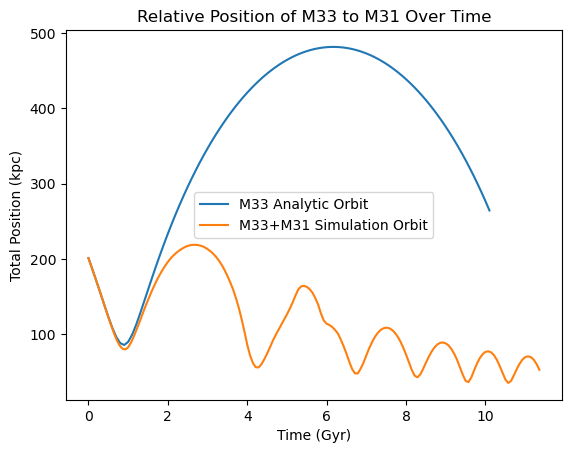

In [40]:
"""
5 ANALYSIS:

1. Create a plot of your predicted M33 orbit from to = 0 Gyr to tmax = 10 Gyr. 
Start with 0.5 Gyr intervals for ∆t and refine (for example, to 0.1 Gyr) once you 
know the code is working. Overplot the solution to Assignment 6 for M33’s orbit with 
respect to M31 from the simulation. Do this for both the total position and total 
velocity as a function of time.

"""

#Creating plot of predicted M33 orbit t0-tmax from new orbit file
import numpy as np
import matplotlib.pyplot as plt

#Orbit data already been saved to 'M33_Orbit.txt' by the OrbitIntegration
orbit_data = np.loadtxt('M33_Orbit.txt')

# Extract time and calculate the distance from origin
time = orbit_data[:, 0]
x = orbit_data[:, 1]
y = orbit_data[:, 2]
z = orbit_data[:, 3]
distance = np.sqrt(x**2 + y**2 + z**2)

# Plotting
fig,ax = plt.subplots()
ax.plot(time, distance, label='M33 Analytic Orbit')
plt.xlabel('Time (Gyr)')
plt.ylabel('Total Position (kpc)')
plt.title('Relative Position of M33 to M31 Over Time')
plt.legend()




#Overplot the position solution to Assignment 6 for M33’s orbit with respect to M31 from the simulation
#Read in Orbit files
M33_Orbit = np.genfromtxt("Orbit_M33.txt") 
M31_Orbit = np.genfromtxt("Orbit_M31.txt") 

# Extract time and calculate the distance
time = M33_Orbit[:, 0]
x1 = M33_Orbit[:, 1]
y1 = M33_Orbit[:, 2]
z1 = M33_Orbit[:, 3]

x2 = M31_Orbit[:, 1]
y2 = M31_Orbit[:, 2]
z2 = M31_Orbit[:, 3]

distance = np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

#Plotting
ax.plot(M33_Orbit[:,0],distance, label="M33+M31 Simulation Orbit") #all of the times, already right length
plt.legend()

plt.show()

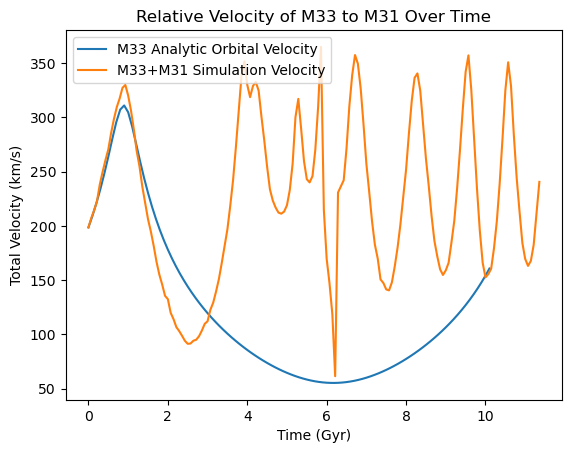

In [41]:
#Creating plot of predicted M33 total velocity t0-tmax from new orbit file
# Extract time and velocity components
time = orbit_data[:, 0]
vx = orbit_data[:, 4]
vy = orbit_data[:, 5]  
vz = orbit_data[:, 6]
velocity_magnitude = np.sqrt(vx**2 + vy**2 + vz**2)  # Calculate the total velocity

# Plotting
fig, ax = plt.subplots()
ax.plot(time, velocity_magnitude, label='M33 Analytic Orbital Velocity')
plt.xlabel('Time (Gyr)')
plt.ylabel('Total Velocity (km/s)')
plt.title('Relative Velocity of M33 to M31 Over Time')
plt.legend()

# Extract time and calculate the distance
time = M33_Orbit[:, 0]
vx1 = M33_Orbit[:, 4]
vy1 = M33_Orbit[:, 5]
vz1 = M33_Orbit[:, 6]

vx2 = M31_Orbit[:, 4]
vy2 = M31_Orbit[:, 5]
vz2 = M31_Orbit[:, 6]

speed = np.sqrt((vx1-vx2)**2 + (vy1-vy2)**2 + (vz1-vz2)**2)



#Overplot the velocity solution to Assignment 6 for M33’s orbit with respect to M31 from the simulation

#M33/M31 Velocity
ax.plot(M33_Orbit[:,0],speed, label="M33+M31 Simulation Velocity") #all of the times, already right length
plt.legend()

plt.show()

In [ ]:
#Part 5: Analysis
"""
2. How do the plots compare?
    For both the total position and total velocity graphs, compared to the simulation, they
    agree in that the first half of the first orbital period. After, they begin to disagree.
    This is because our analytic solution does not include the significant effects of
    the MW on the orbit. M33 orbits M31 much slower when the MW is not included in the
    analytic solution. MW is so big so it makes a huge difference in M33's orbit.

3. What missing physics could make the difference?
    We are completely missing the effects of the MW in our analytic solution. Therefore,
    we would need to do a whole 3-Body analytic calculation that includes effects from
    the MW on both Andromeda and M33. This calculation requires much more care as it is
    a very sensative system where small mistakes could lead to large compiled errors.


4. The MW is missing in these calculations. How might you include its effects?
    One approximation could be to combine the masses of M31 and the MW at their COM. Then,
    we could have M33 orbit this object. This would be much simpler than considering the full 
    3-Body problem.
"""